# Ethan Li
## CSCI E-89 Deep Learning, Assignment 03, Problem 2

**Fashion MNIST image classification with a PyTorch MLP.**

This notebook trains a multilayer perceptron (784 → 300 → 100 → 10, ReLU) to classify the
10 clothing categories of Fashion MNIST. It covers the whole pipeline in order:

1. **Data**: download, seed 42, 55,000 / 5,000 train/validation split, normalization, DataLoaders (batch size 32)
2. **Model**: the MLP as an `nn.Module`
3. **Plotting helpers**: training vs. validation accuracy chart
4. **Training**: SGD (lr 0.1) + cross-entropy for 20 epochs, torchmetrics accuracy, test evaluation, saving weights and history
5. **Predictions**: softmax probabilities and top-4 classes for 3 validation images
6. **Hyperparameter tuning**: Optuna search over learning rate, hidden-layer sizes and momentum (30 trials × 5 epochs), then retraining the best configuration and comparing it with the baseline

The code was developed step by step as separate scripts with Claude Code. Before each code cell, a markdown
cell explains the step and quotes the request that produced it. The notebook is self-contained (it does not
import the `.py` files) and runs top to bottom with **Kernel → Restart & Run All** (about 8–10 minutes on a CPU).

**Requirements:** `torch`, `torchvision`, `torchmetrics`, `matplotlib`, `optuna`, `pandas`
(e.g. `pip install torch torchvision torchmetrics matplotlib optuna pandas`).

**Results in brief:** baseline test accuracy **88.94%**; best Optuna configuration **88.91%**, essentially a tie.
The baseline's hyperparameters were already close to optimal for this search space.

## 1. Data loading and preprocessing

This cell prepares everything the later cells use:

- **Reproducibility:** seeds Python, NumPy and PyTorch with 42 and makes cuDNN deterministic.
- **Device:** uses a GPU if available (CUDA, or Apple MPS), otherwise the CPU.
- **Download:** fetches Fashion MNIST with `torchvision.datasets.FashionMNIST` into `./data/`.
- **Split:** a seeded random permutation splits the 60,000 training images into **55,000 train** and **5,000 validation**.
- **Tensors and normalization:** `ToTensor()` converts each image to a `float32` tensor (1×28×28, values in [0, 1]),
  and `Normalize` standardizes it with the mean and standard deviation of the **training split only**, so no
  validation or test data leaks into preprocessing.
- **DataLoaders:** batch size 32. Only the training loader shuffles, with a seeded generator.
  `num_workers=0` avoids multiprocessing problems inside Jupyter.
- **Sanity check:** prints split sizes and one batch's shape and dtype.

**Prompt 1** (from `PROMPTS.md`):

> Hello! I'd like your help in building an image classifier for the Fashion MNIST dataset with PyTorch. For each major step, write and commit a separate Python file.
>
> Some things additional things worth noting:
>
> 1. Part of the final goal includes creating a Jupyter Notebook containing all the scripts. Thus, make the scripts compatible with being pasted into Jupyter Notebook cells
> 2. Keep a file, PROMPTS.md, that logs each one of my requests. At the end of the project, I'll have you write a summary of the entire chat. The PROMPTS.md file may be useful for that :)
>
> Okay. The first step is to write "data.py". This should handle downloading Fashion MNIST with torchvision, converting and normalizing vectors to float32 tensors, setting the seed (42), splitting the 60,000 training images into 55,000 for training and 5,000 for validation, creating dataloaders with batch size 32, and whatever else is necessary.

In [1]:
# ----------------------------- Imports ---------------------------------------
import random

import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# ----------------------------- Configuration ---------------------------------
SEED = 42
DATA_DIR = "./data"   # where torchvision stores the downloaded files
BATCH_SIZE = 32
NUM_TRAIN = 55_000
NUM_VAL = 5_000
NUM_WORKERS = 0       # 0 avoids multiprocessing issues inside Jupyter on macOS/Windows

# Human-readable names for label indices 0..9
CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]


# ----------------------------- Reproducibility -------------------------------
def set_seed(seed=SEED):
    """Seed Python, NumPy, and PyTorch (CPU and GPU) RNGs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True  # deterministic GPU kernels
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

# Use a GPU when one is available (NVIDIA CUDA or Apple MPS), otherwise the CPU.
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)


# ----------------------------- Train/val split -------------------------------
# Download once without transforms to get the dataset size and raw pixel values.
_raw_train = datasets.FashionMNIST(root=DATA_DIR, train=True, download=True)
assert len(_raw_train) == NUM_TRAIN + NUM_VAL, "Unexpected training set size"

# Seeded permutation of 0..59,999 -> identical split every run.
_split_gen = torch.Generator().manual_seed(SEED)
_perm = torch.randperm(len(_raw_train), generator=_split_gen)
train_indices = _perm[:NUM_TRAIN].tolist()   # first 55,000 shuffled indices
val_indices = _perm[NUM_TRAIN:].tolist()     # remaining 5,000


# ----------------------------- Normalization ---------------------------------
# Compute mean/std over the training split only. `.data` is a uint8 tensor of
# shape (60000, 28, 28); scale to [0, 1] float32 to match ToTensor().
_train_pixels = _raw_train.data[train_indices].to(torch.float32) / 255.0
MEAN = _train_pixels.mean().item()
STD = _train_pixels.std().item()
del _train_pixels  # free memory

# ToTensor(): PIL image (uint8, HxW) -> float32 tensor (1x28x28) in [0, 1]
# Normalize(): (x - MEAN) / STD
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])


# ----------------------------- Datasets --------------------------------------
_full_train = datasets.FashionMNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root=DATA_DIR, train=False, download=True, transform=transform)

# Both subsets share the same transformed dataset, indexed by the split above.
train_dataset = Subset(_full_train, train_indices)
val_dataset = Subset(_full_train, val_indices)


# ----------------------------- DataLoaders -----------------------------------
def _seed_worker(worker_id):
    """Keep per-worker RNGs reproducible if NUM_WORKERS > 0."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


_loader_gen = torch.Generator().manual_seed(SEED)  # makes shuffling order reproducible
_pin_memory = device.type == "cuda"                # faster host->GPU copies on CUDA

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=_pin_memory,
    worker_init_fn=_seed_worker, generator=_loader_gen,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=_pin_memory,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=_pin_memory,
)


# ----------------------------- Sanity check ----------------------------------
print(f"Device: {device}")
print(f"Normalization: mean={MEAN:.4f}, std={STD:.4f}")
print(f"Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}")
print(f"Batches -> train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}")

# Peek at one training batch. Drawing from train_loader advances its seeded
# shuffling generator, so save and restore its state: training then sees the
# exact same shuffle order as if this check had never run.
_gen_state = _loader_gen.get_state()
images, labels = next(iter(train_loader))
_loader_gen.set_state(_gen_state)
print(f"Batch images: shape={tuple(images.shape)}, dtype={images.dtype}")
print(f"Batch labels: shape={tuple(labels.shape)}, dtype={labels.dtype}")
print(f"Batch pixel mean={images.mean():.3f}, std={images.std():.3f}")
print(f"First labels: {[CLASS_NAMES[i] for i in labels[:5].tolist()]}")

  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 32.8k/26.4M [00:00<01:25, 309kB/s]

  0%|          | 65.5k/26.4M [00:00<01:26, 303kB/s]

  0%|          | 98.3k/26.4M [00:00<01:27, 302kB/s]

  1%|          | 229k/26.4M [00:00<00:39, 657kB/s] 

...

 82%|████████▏ | 3.64M/4.42M [00:00<00:00, 8.17MB/s]

100%|██████████| 4.42M/4.42M [00:00<00:00, 5.06MB/s]

  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<00:00, 10.0MB/s]

Device: cpu
Normalization: mean=0.2856, std=0.3527
Train: 55,000 | Val: 5,000 | Test: 10,000
Batches -> train: 1719, val: 157, test: 313
Batch images: shape=(32, 1, 28, 28), dtype=torch.float32
Batch labels: shape=(32,), dtype=torch.int64
Batch pixel mean=0.158, std=1.068
First labels: ['T-shirt/top', 'Shirt', 'Sneaker', 'Shirt', 'Trouser']


## 2. Model: MLP classifier

Defines `MLPClassifier`, an `nn.Module`:

```
Input (1×28×28) → Flatten (784)
→ Linear(784, 300) → ReLU
→ Linear(300, 100) → ReLU
→ Linear(100, 10)  → 10 logits (one per class)
```

The output is **raw logits** (no softmax), because `nn.CrossEntropyLoss` applies log-softmax internally.
The hidden-layer sizes are constructor arguments so the tuning step can reuse the class. The model has
**266,610** trainable parameters. The seed is set again right before the model is created so its initial
weights are reproducible, and a dummy batch checks the output shape.

**Prompt 2** (from `PROMPTS.md`):

> Nice. Next, write model.py with a MLP classifier as an nn.Module. Flatten the 28x28 image, then use two hidden layers of 300 and 100 neurons with ReLU. The output layer should be 10 logits (one per class).

In [2]:
from torch import nn

INPUT_DIM = 28 * 28      # flattened image size
HIDDEN_DIMS = (300, 100) # neurons in hidden layers 1 and 2
NUM_CLASSES = 10


class MLPClassifier(nn.Module):
    """Multilayer perceptron: 784 -> 300 -> 100 -> 10 with ReLU activations."""

    def __init__(self, input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES):
        super().__init__()
        h1, h2 = hidden_dims
        self.flatten = nn.Flatten()  # (N, 1, 28, 28) -> (N, 784)
        self.layers = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, num_classes),  # no softmax: CrossEntropyLoss expects logits
        )

    def forward(self, x):
        return self.layers(self.flatten(x))  # logits, shape (N, num_classes)


def count_parameters(model):
    """Number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Re-seed right before construction so weight initialization is reproducible
# regardless of how many random draws happened in earlier cells.
torch.manual_seed(42)
model = MLPClassifier().to(device)

# ----------------------------- Sanity check ----------------------------------
print(model)
print(f"Trainable parameters: {count_parameters(model):,}")

dummy = torch.randn(32, 1, 28, 28, device=device)  # fake batch of 32 images
with torch.no_grad():
    out = model(dummy)
print(f"Input shape: {tuple(dummy.shape)} -> Output shape: {tuple(out.shape)}")

MLPClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=300, bias=True)
    (1): ReLU()
    (2): Linear(in_features=300, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)
Trainable parameters: 266,610
Input shape: (32, 1, 28, 28) -> Output shape: (32, 10)


## 3. Plotting helpers

Defines `plot_accuracy` / `plot_history`, which draw **training and validation accuracy per epoch on one chart**,
with the final test accuracy as a dashed reference line and each line's last value labeled at its end.
The colors are colorblind-safe. The chart is saved as `accuracy.png` and shown inline in Jupyter (`plt.show()` is
only called inside a notebook kernel; a plain script just saves the file).

This cell comes **before** training because the training cell calls `plot_history(history)` when it finishes.
(The standalone `plot.py` could also redraw the chart from `history.json`; in the notebook, the training cell
draws it directly.)

**Prompt 4** (from `PROMPTS.md`):

> You've guessed it again :)
>
> Write plot.py to plot the training accuracy per epoch. Put validation accuracy on the same chart for comparison. Save it as png, but make it display them inline when running in Jupyter. Have train.py call the plotting after training. Regenerate the plots from history.json, then commit with the images and update PROMPTS.md.

In [3]:
import matplotlib.pyplot as plt

ACCURACY_PLOT_PATH = "accuracy.png"

# Colors: categorical slots 1 and 2 of a colorblind-validated palette;
# text/grid use neutral inks so identity is carried by the lines + labels.
TRAIN_COLOR = "#2a78d6"   # blue
VAL_COLOR = "#eb6834"     # orange
TEST_COLOR = "#8a8984"    # neutral gray (reference line)
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID_COLOR = "#e4e3df"


def _in_notebook():
    """True when running inside a Jupyter/IPython kernel."""
    try:
        from IPython import get_ipython
        shell = get_ipython()
        return shell is not None and shell.__class__.__name__ == "ZMQInteractiveShell"
    except ImportError:
        return False


def _show_or_close(fig):
    """Display inline in Jupyter; otherwise just free the figure."""
    if _in_notebook():
        plt.show()
    else:
        plt.close(fig)


def plot_accuracy(history, save_path=ACCURACY_PLOT_PATH):
    """Training and validation accuracy per epoch on one chart."""
    # Convert fractions to percentages for readability.
    train_acc = [a * 100 for a in history["train_acc"]]
    val_acc = [a * 100 for a in history["val_acc"]]
    epochs = range(1, len(train_acc) + 1)

    fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
    ax.plot(epochs, train_acc, color=TRAIN_COLOR, linewidth=2,
            marker="o", markersize=5, label="Training")
    ax.plot(epochs, val_acc, color=VAL_COLOR, linewidth=2,
            marker="o", markersize=5, label="Validation")

    # Dashed horizontal line at the final test accuracy, if it has been computed.
    if "test_acc" in history:
        test_acc = history["test_acc"] * 100
        ax.axhline(test_acc, color=TEST_COLOR, linewidth=1.2, linestyle="--",
                   label=f"Test (final): {test_acc:.2f}%")

    # Direct labels at the end of each line (value in text ink, not series color).
    for series in (train_acc, val_acc):
        ax.annotate(f"{series[-1]:.2f}%", xy=(epochs[-1], series[-1]),
                    xytext=(8, 0), textcoords="offset points",
                    va="center", fontsize=9, color=TEXT_PRIMARY)

    ax.set_title("Training vs. validation accuracy", color=TEXT_PRIMARY,
                 fontsize=13, loc="left", pad=12)
    ax.set_xlabel("Epoch", color=TEXT_SECONDARY)
    ax.set_ylabel("Accuracy (%)", color=TEXT_SECONDARY)
    ax.set_xticks(list(epochs))
    ax.set_xlim(0.5, epochs[-1] + 1.5)  # room for the end labels

    # Recessive axes and grid.
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID_COLOR)
    ax.tick_params(colors=TEXT_SECONDARY, labelsize=9)

    ax.legend(frameon=False, loc="lower right", labelcolor=TEXT_PRIMARY)
    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight")  # always save the PNG
    print(f"Saved accuracy plot to {save_path}")
    _show_or_close(fig)                          # inline in Jupyter


def plot_history(history):
    """Generate all training plots from a history dict (called after training)."""
    plot_accuracy(history)


print("Plotting helpers defined: plot_accuracy(), plot_history()")

Plotting helpers defined: plot_accuracy(), plot_history()


## 4. Training the baseline model

Trains the MLP from Section 2:

- **Optimizer:** SGD with learning rate 0.1. **Loss:** cross-entropy.
- **20 epochs.** After each epoch, it records the **mean training loss** (weighted by batch size, so the smaller
  final batch doesn't skew it), **training accuracy** and **validation accuracy** in the `history` dict and prints them.
- **Accuracy** uses torchmetrics `MulticlassAccuracy(average="micro")`, i.e. plain correct ÷ total.
  (torchmetrics defaults to `"macro"`, the average of per-class accuracies.)
- Runs on the GPU if one is available (the `device` from Section 1), otherwise the CPU.
- **After training:** evaluates **test accuracy**, adds it to `history`, saves the weights (`mlp_fashion_mnist.pt`)
  and the history (`history.json`), and draws the accuracy chart with `plot_history` from Section 3.

Expected result: about **95% training / 89% validation / 88.9% test** accuracy. Validation accuracy levels off
after about epoch 8 while training accuracy keeps rising, which shows mild overfitting.

**Prompt 3** (from `PROMPTS.md`):

> You got it! Write train.py -- train the model with SGD (learning rate 0.1) and cross-entropy loss for 20 epochs, using torchmetrics to compute multiclass accuracy. For each epoch, record the mean training loss, training accuracy, and validation accuracy in a variable and print them. Use a GPU if one is available, otherwise CPU is fine. After training, evaluate accuracy on the test set, save the model weights, and save the history (including test accuracy). Just as a reminder, make sure you also update PROMPTS.md.

Training on cpu for 20 epochs (SGD, lr=0.1)


Epoch  1/20 | train loss 0.4927 | train acc 0.8182 | val acc 0.8558


Epoch  2/20 | train loss 0.3597 | train acc 0.8662 | val acc 0.8612


Epoch  3/20 | train loss 0.3169 | train acc 0.8821 | val acc 0.8722


Epoch  4/20 | train loss 0.2910 | train acc 0.8904 | val acc 0.8772


...

Epoch 18/20 | train loss 0.1378 | train acc 0.9469 | val acc 0.8916


Epoch 19/20 | train loss 0.1334 | train acc 0.9491 | val acc 0.8882


Epoch 20/20 | train loss 0.1278 | train acc 0.9505 | val acc 0.8908
Training time: 216.4s


Test accuracy: 0.8894
Saved weights to mlp_fashion_mnist.pt and history to history.json


Saved accuracy plot to accuracy.png


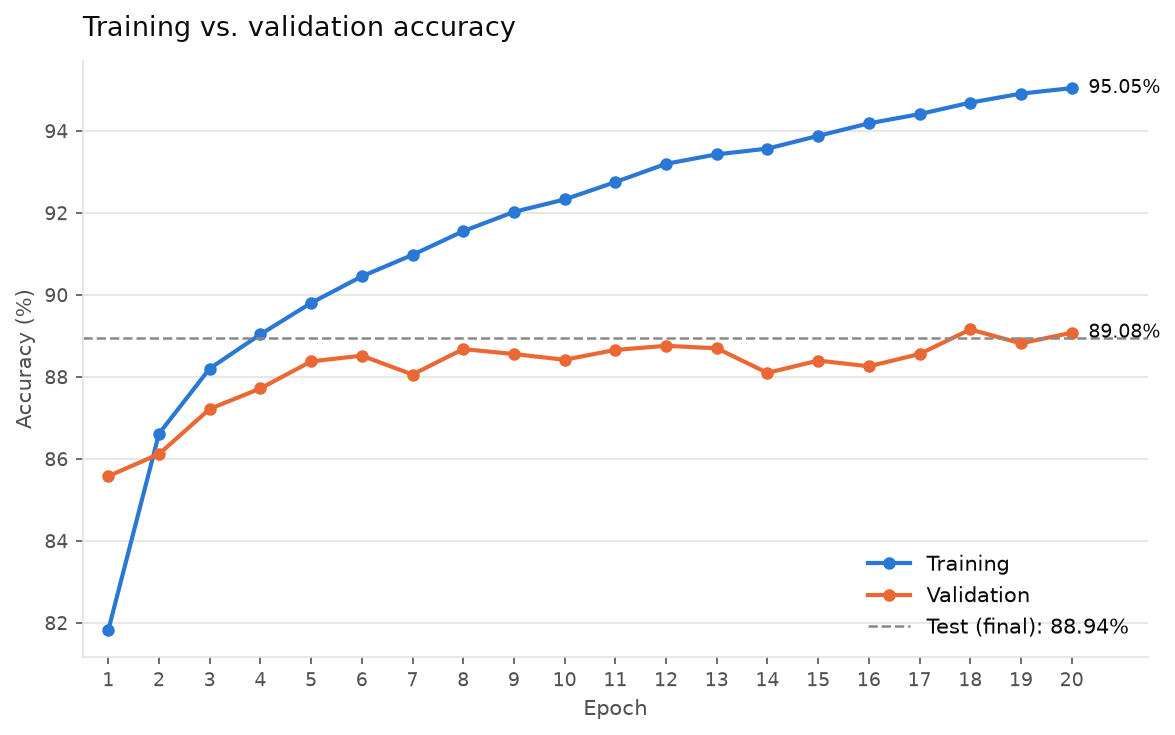

In [4]:
import json
import time

from torchmetrics.classification import MulticlassAccuracy

# ----------------------------- Configuration ---------------------------------
NUM_EPOCHS = 20
LEARNING_RATE = 0.1
WEIGHTS_PATH = "mlp_fashion_mnist.pt"
HISTORY_PATH = "history.json"

model = model.to(device)
criterion = nn.CrossEntropyLoss()  # applies log-softmax + negative log-likelihood
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)

# average="micro" gives standard accuracy (correct / total). torchmetrics'
# default for MulticlassAccuracy is "macro" (mean of per-class accuracies).
train_metric = MulticlassAccuracy(num_classes=NUM_CLASSES, average="micro").to(device)
eval_metric = MulticlassAccuracy(num_classes=NUM_CLASSES, average="micro").to(device)


# ----------------------------- Helpers ---------------------------------------
def train_one_epoch(model, loader, criterion, optimizer, metric, device):
    """One pass over `loader`. Returns (mean loss per sample, accuracy)."""
    model.train()
    metric.reset()
    total_loss, total_samples = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()              # clear gradients from the previous step
        logits = model(images)             # forward pass
        loss = criterion(logits, labels)
        loss.backward()                    # backpropagation
        optimizer.step()                   # SGD update

        # Weight by batch size so a smaller final batch doesn't skew the mean.
        total_loss += loss.item() * labels.size(0)
        total_samples += labels.size(0)
        metric.update(logits.detach(), labels)  # accumulate accuracy over the epoch
    return total_loss / total_samples, metric.compute().item()


@torch.no_grad()
def evaluate(model, loader, metric, device):
    """Accuracy of `model` on `loader` (no gradient tracking)."""
    model.eval()
    metric.reset()
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        metric.update(model(images), labels)
    return metric.compute().item()


# ----------------------------- Training loop ---------------------------------
history = {"train_loss": [], "train_acc": [], "val_acc": []}

print(f"Training on {device} for {NUM_EPOCHS} epochs (SGD, lr={LEARNING_RATE})")
start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, train_metric, device)
    val_acc = evaluate(model, val_loader, eval_metric, device)

    # Record this epoch's metrics.
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"train loss {train_loss:.4f} | train acc {train_acc:.4f} | val acc {val_acc:.4f}")
print(f"Training time: {time.time() - start:.1f}s")


# ----------------------------- Test + save -----------------------------------
test_acc = evaluate(model, test_loader, eval_metric, device)
history["test_acc"] = test_acc
print(f"Test accuracy: {test_acc:.4f}")

torch.save(model.state_dict(), WEIGHTS_PATH)   # weights only (state_dict)
with open(HISTORY_PATH, "w") as f:
    json.dump(history, f, indent=2)
print(f"Saved weights to {WEIGHTS_PATH} and history to {HISTORY_PATH}")

# ----------------------------- Plots -----------------------------------------
plot_history(history)  # defined in Section 3

## 5. Predictions on validation images

Uses the trained model on the **first 3 images of the validation set**. It reloads the weights saved in Section 4
(`map_location` lets weights trained on a GPU load on a CPU), runs the 3 images as one batch, and applies
**softmax** to turn the logits into probabilities. For each image it prints:

- the **predicted** and **true** class names, and whether the prediction is correct
- the softmax probability for **all 10 classes**, rounded to 3 decimals
- the **top 4** most likely classes (via `torch.topk`)

Expected result: all 3 are correct: Sneaker (0.999), Coat (0.995, runner-up Pullover) and Pullover
(0.987, runner-up Shirt). Each runner-up is a similar-looking item.

**Prompt 5** (from `PROMPTS.md`):

> Lets do some predictions now. Write predict.py to use the trained model: take the first 3 images from the validation set, print the predicted and true class names, the softmax probabilities for all 10 classes (rounded to 3 decimals), and the top 4 most likely classes for each image. Again, it should for Jupyter Notebook. Commit and update PROMPTS.md.

In [5]:
# ----------------------------- Configuration ---------------------------------
WEIGHTS_PATH = "mlp_fashion_mnist.pt"
NUM_IMAGES = 3
TOP_K = 4

# Load the trained weights (map_location lets GPU-trained weights load on CPU).
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
model = model.to(device)
model.eval()  # inference mode

# ----------------------------- Predict ---------------------------------------
# Stack the first NUM_IMAGES validation samples into one batch: (3, 1, 28, 28).
images = torch.stack([val_dataset[i][0] for i in range(NUM_IMAGES)]).to(device)
true_labels = [val_dataset[i][1] for i in range(NUM_IMAGES)]

with torch.no_grad():
    logits = model(images)
    probs = torch.softmax(logits, dim=1).cpu()  # (3, 10), each row sums to 1

pred_labels = probs.argmax(dim=1).tolist()     # most likely class per image
top_probs, top_idx = probs.topk(TOP_K, dim=1)  # 4 highest probabilities + their classes

# ----------------------------- Report ----------------------------------------
name_width = max(len(name) for name in CLASS_NAMES)  # for column alignment

for i in range(NUM_IMAGES):
    pred, true = pred_labels[i], true_labels[i]
    status = "correct" if pred == true else "WRONG"
    print(f"=== Validation image {i} ===")
    print(f"Predicted: {CLASS_NAMES[pred]}  |  True: {CLASS_NAMES[true]}  ({status})")

    print("Softmax probabilities:")
    for c, name in enumerate(CLASS_NAMES):
        print(f"  {c}  {name:<{name_width}}  {probs[i, c].item():.3f}")

    print(f"Top {TOP_K} classes:")
    for rank, (p, c) in enumerate(zip(top_probs[i].tolist(), top_idx[i].tolist()), start=1):
        print(f"  {rank}. {CLASS_NAMES[c]:<{name_width}}  {p:.3f}")
    print()

=== Validation image 0 ===
Predicted: Sneaker  |  True: Sneaker  (correct)
Softmax probabilities:
  0  T-shirt/top  0.000
  1  Trouser      0.000
  2  Pullover     0.000
  3  Dress        0.000
  4  Coat         0.000
  5  Sandal       0.000
  6  Shirt        0.000
  7  Sneaker      0.999
  8  Bag          0.000
  9  Ankle boot   0.000
Top 4 classes:
  1. Sneaker      0.999
  2. Ankle boot   0.000
  3. Sandal       0.000
  4. Coat         0.000

=== Validation image 1 ===
Predicted: Coat  |  True: Coat  (correct)
Softmax probabilities:
  0  T-shirt/top  0.000
  1  Trouser      0.000
  2  Pullover     0.005
  3  Dress        0.000
  4  Coat         0.995
  5  Sandal       0.000
  6  Shirt        0.000
  7  Sneaker      0.000
  8  Bag          0.000
  9  Ankle boot   0.000
Top 4 classes:
  1. Coat         0.995
  2. Pullover     0.005
  3. Shirt        0.000
  4. Dress        0.000

=== Validation image 2 ===
Predicted: Pullover  |  True: Pullover  (correct)
Softmax probabilities:
  0  T

## 6. Hyperparameter tuning with Optuna

Searches for better hyperparameters (still SGD + cross-entropy, batch size 32):

| Hyperparameter | Range |
|---|---|
| Learning rate | 1e-5 to 1e-1, log scale |
| Hidden layer 1 neurons | 50–500 (step 25) |
| Hidden layer 2 neurons | 25–300 (step 25) |
| SGD momentum | 0.0–0.99 |

- **Search:** 30 trials × 5 epochs, maximizing validation accuracy, with a TPE sampler (seed 42). A median
  pruner stops clearly bad trials after their first epoch. The first run used 10 trials; it was raised to 30
  after that run (prompt 7) so the search could explore learning rates closer to the baseline's 0.1.
- **Speed:** each dataset is loaded into memory once as a tensor on `device`, and batches are sliced from it,
  which skips the DataLoader's per-image conversion. The data, normalization and batch size are identical,
  and a 5-epoch trial takes seconds instead of close to a minute.
- **Output:** a table of all trials and the best parameters. The best configuration is then **retrained for 20 epochs**,
  and its test accuracy is compared with the baseline from Section 4. Results are saved to `optuna_trials.csv`,
  `tuning_results.json` and `mlp_fashion_mnist_tuned.pt`.

Expected result: best trial #26 (lr ≈ 0.050, hidden 200/200, momentum ≈ 0.26) reaches **88.91%** test accuracy
against the baseline's **88.94%**, essentially a tie. Its effective step size, lr / (1 − momentum) ≈ 0.067,
is close to the baseline's 0.1, so the search mostly rediscovered the baseline settings.

**Prompt 6 — first tuning run (10 trials)** (from `PROMPTS.md`):

> Actually, let's now try some hyperparameter tuning. Use Optuna to search the learning rate (log scale from about 1e-5 to 1e-1), the number of neurons in each hidden layer, and the optimizer momentum. Try your best to keep it fast; maybe do about 10 trials of 5 epochs each. Print a table of the trials and the best parameters, then retrain the best configuration for 20 epochs and report its test accuracy compared with the baseline from train.py. Commit the results and update PROMPTS.md again.

**Prompt 7 — re-run with 30 trials** (from `PROMPTS.md`):

> Try that please, thank you!

*(Prompt 7 answered my suggestion to run a 30-trial search.)*

In [6]:
import optuna

# ----------------------------- Configuration ---------------------------------
N_TRIALS = 30       # raised from 10 (prompt 7)
TUNE_EPOCHS = 5     # epochs per trial
FINAL_EPOCHS = 20   # epochs to retrain the best configuration
TRIALS_CSV_PATH = "optuna_trials.csv"
RESULTS_PATH = "tuning_results.json"
TUNED_WEIGHTS_PATH = "mlp_fashion_mnist_tuned.pt"


# ----------------------------- Fast in-memory data ---------------------------
def to_tensors(dataset):
    """Materialize a dataset as (images, labels) tensors on `device`."""
    # One batch containing the whole dataset -> a single (N, 1, 28, 28) tensor.
    images, labels = next(iter(DataLoader(dataset, batch_size=len(dataset))))
    return images.to(device), labels.to(device)


def batches(images, labels, batch_size, shuffle, generator=None):
    """Yield (images, labels) mini-batches, like a DataLoader would."""
    n = labels.size(0)
    order = (torch.randperm(n, generator=generator).to(device) if shuffle
             else torch.arange(n, device=device))
    for start in range(0, n, batch_size):
        idx = order[start:start + batch_size]
        yield images[idx], labels[idx]


print("Loading datasets into memory...")
X_train, y_train = to_tensors(train_dataset)
X_val, y_val = to_tensors(val_dataset)
X_test, y_test = to_tensors(test_dataset)


# ----------------------------- Train / evaluate ------------------------------
def fit_one_epoch(model, optimizer, criterion, generator):
    """One training epoch over the in-memory training tensors."""
    model.train()
    for images, labels in batches(X_train, y_train, BATCH_SIZE, shuffle=True, generator=generator):
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()


@torch.no_grad()
def accuracy(model, images, labels):
    """Plain (micro-averaged) multiclass accuracy via torchmetrics."""
    model.eval()
    metric = MulticlassAccuracy(num_classes=NUM_CLASSES, average="micro").to(device)
    for xb, yb in batches(images, labels, 1024, shuffle=False):  # large batches: eval only
        metric.update(model(xb), yb)
    return metric.compute().item()


def build(params):
    """Seeded model + SGD optimizer for a set of hyperparameters."""
    torch.manual_seed(SEED)  # same initialization procedure for every trial
    model = MLPClassifier(hidden_dims=(params["hidden1"], params["hidden2"])).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=params["lr"], momentum=params["momentum"])
    return model, optimizer


# ----------------------------- Optuna objective ------------------------------
def objective(trial):
    """Train one configuration for TUNE_EPOCHS and return validation accuracy."""
    params = {
        "lr": trial.suggest_float("lr", 1e-5, 1e-1, log=True),           # log-scale search
        "hidden1": trial.suggest_int("hidden1", 50, 500, step=25),
        "hidden2": trial.suggest_int("hidden2", 25, 300, step=25),
        "momentum": trial.suggest_float("momentum", 0.0, 0.99),
    }
    model, optimizer = build(params)
    criterion = nn.CrossEntropyLoss()
    gen = torch.Generator().manual_seed(SEED)  # same shuffling order for every trial

    val_acc = 0.0
    for epoch in range(1, TUNE_EPOCHS + 1):
        fit_one_epoch(model, optimizer, criterion, gen)
        val_acc = accuracy(model, X_val, y_val)
        trial.report(val_acc, epoch)       # let the pruner see intermediate results
        if trial.should_prune():           # stop clearly bad trials early
            raise optuna.TrialPruned()
    return val_acc


optuna.logging.set_verbosity(optuna.logging.WARNING)  # keep the output compact
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),                          # reproducible search
    pruner=optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=1),
)

print(f"Running {N_TRIALS} trials x up to {TUNE_EPOCHS} epochs on {device}...")
start = time.time()
study.optimize(objective, n_trials=N_TRIALS)
print(f"Search time: {time.time() - start:.1f}s\n")


# ----------------------------- Trials table ----------------------------------
# Tidy the Optuna dataframe: drop the "params_" prefix and order the columns.
trials_df = study.trials_dataframe(attrs=("number", "value", "params", "state"))
trials_df = trials_df.rename(columns=lambda c: c.replace("params_", ""))
trials_df = trials_df.rename(columns={"value": "val_acc"})
trials_df = trials_df[["number", "state", "val_acc", "lr", "momentum", "hidden1", "hidden2"]]
trials_df.to_csv(TRIALS_CSV_PATH, index=False)

print("Trials:")
print(trials_df.to_string(index=False, formatters={
    "val_acc": lambda v: f"{v:.4f}",
    "lr": lambda v: f"{v:.2e}",
    "momentum": lambda v: f"{v:.3f}",
}))

best_params = study.best_params
print(f"\nBest trial: #{study.best_trial.number} (val acc {study.best_value:.4f})")
print("Best parameters:")
for name, value in best_params.items():
    print(f"  {name:<9} {value:.3e}" if name == "lr" else f"  {name:<9} {value}")


# ----------------------------- Retrain best ----------------------------------
print(f"\nRetraining best configuration for {FINAL_EPOCHS} epochs...")
model_tuned, optimizer = build(best_params)
criterion = nn.CrossEntropyLoss()
gen = torch.Generator().manual_seed(SEED)
tuned_history = {"val_acc": []}
for epoch in range(1, FINAL_EPOCHS + 1):
    fit_one_epoch(model_tuned, optimizer, criterion, gen)
    val_acc = accuracy(model_tuned, X_val, y_val)
    tuned_history["val_acc"].append(val_acc)
    print(f"Epoch {epoch:2d}/{FINAL_EPOCHS} | val acc {val_acc:.4f}")

tuned_test_acc = accuracy(model_tuned, X_test, y_test)
torch.save(model_tuned.state_dict(), TUNED_WEIGHTS_PATH)


# ----------------------------- Compare with baseline -------------------------
baseline_test_acc = history["test_acc"]  # from the training cell (Section 4)

print("\n=== Test accuracy ===")
print(f"{'Baseline (train.py: lr=0.1, momentum=0, 300/100)':<50} {baseline_test_acc:.4f}")
print(f"{'Tuned (Optuna best, retrained ' + str(FINAL_EPOCHS) + ' epochs)':<50} {tuned_test_acc:.4f}")
diff = tuned_test_acc - baseline_test_acc
print(f"Difference: {diff * 100:+.2f} percentage points")

with open(RESULTS_PATH, "w") as f:
    json.dump({
        "n_trials": N_TRIALS,
        "tune_epochs": TUNE_EPOCHS,
        "best_trial": study.best_trial.number,
        "best_val_acc_during_search": study.best_value,
        "best_params": best_params,
        "final_epochs": FINAL_EPOCHS,
        "tuned_val_acc": tuned_history["val_acc"],
        "tuned_test_acc": tuned_test_acc,
        "baseline_test_acc": baseline_test_acc,
    }, f, indent=2)
print(f"\nSaved trials to {TRIALS_CSV_PATH}, results to {RESULTS_PATH}, "
      f"weights to {TUNED_WEIGHTS_PATH}")

Loading datasets into memory...


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running 30 trials x up to 5 epochs on cpu...


Search time: 170.2s

Trials:
 number    state val_acc       lr momentum  hidden1  hidden2
      0 COMPLETE  0.7800 3.15e-04    0.593      500      225
      1 COMPLETE  0.6720 4.21e-05    0.858      100       25
      2 COMPLETE  0.8672 2.54e-03    0.960      375       25
      3 COMPLETE  0.8684 2.14e-02    0.182      150       75
      4   PRUNED  0.5094 1.65e-04    0.288      275      150
      5 COMPLETE  0.8432 2.80e-03    0.363      100      100
      6   PRUNED  0.7132 6.67e-04    0.509      400       75
      7   PRUNED  0.7564 2.34e-03    0.169       50      200
      8   PRUNED  0.3822 1.82e-05    0.800      500      300
      9   PRUNED  0.4334 1.65e-04    0.436       75      225
     10 COMPLETE  0.8496 3.98e-02    0.895      100      100
     11 COMPLETE  0.8750 2.59e-02    0.575      150       25
     12   PRUNED  0.8450 2.62e-02    0.165      225       25
     13 COMPLETE  0.8698 4.45e-02    0.654      275       75
     14 COMPLETE  0.8774 3.36e-02    0.560      200     

Epoch  1/20 | val acc 0.8484


...

Epoch 16/20 | val acc 0.8870


Epoch 17/20 | val acc 0.8870


Epoch 18/20 | val acc 0.8886


Epoch 19/20 | val acc 0.8882


Epoch 20/20 | val acc 0.8934

=== Test accuracy ===
Baseline (train.py: lr=0.1, momentum=0, 300/100)   0.8894
Tuned (Optuna best, retrained 20 epochs)           0.8891
Difference: -0.03 percentage points

Saved trials to optuna_trials.csv, results to tuning_results.json, weights to mlp_fashion_mnist_tuned.pt


## Conclusion

| Model | Learning rate | Momentum | Hidden layers | Test accuracy |
|---|---|---|---|---|
| Baseline (Section 4) | 0.1 | 0 | 300 / 100 | **88.94%** |
| Optuna best, 30 trials (Section 6) | ≈ 0.050 | ≈ 0.26 | 200 / 200 | **88.91%** |

- The baseline MLP reaches about **89% test accuracy**. Training accuracy keeps rising to 95% while validation accuracy
  levels off near 89%, so the model starts to overfit after about 8 epochs.
- The model is confident and correct on the sampled validation images, and its runner-up guesses are similar-looking
  clothing (coat ↔ pullover ↔ shirt).
- Optuna **did not beat the baseline**. With 10 trials the best configuration scored 88.50%; with 30 trials it tied at
  88.91%. The baseline hyperparameters were already near-optimal for this search space, so about 89% is the practical
  ceiling for this architecture. Going further would take regularization (dropout, weight decay) or a convolutional network.